Practising PCA

In [8]:
# Using the Linear Algebra
# Using the Plots, using the Statistics
import numpy as np
import matplotlib.pyplot as plt
import statistics

In [6]:
### Defing the Dataset
x = [
    [2.5, 2.4],
    [0.5, 0.7],
    [2.2, 2.9],
    [1.9, 2.2],
    [3.1, 3.0],
    [2.3, 2.7],
    [2.0, 1.6],
    [1.0, 1.1],
    [1.5, 1.6],
    [1.1, 0.9]
]

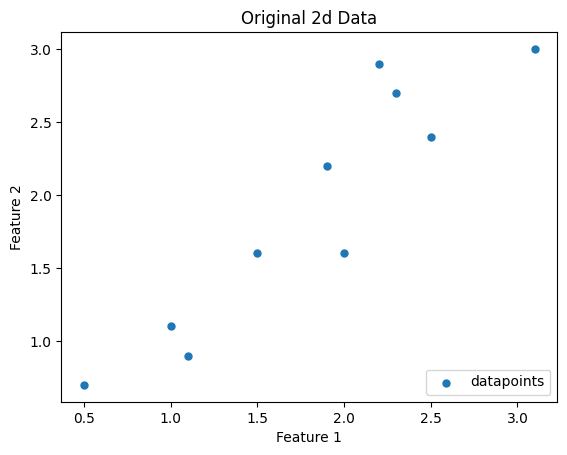

In [16]:
## 2) Scatter plot of the Original 2d Data
x_np = np.array(x)
plt.scatter(x_np[:, 0], x_np[:, 1], label='datapoints', marker='o', s=25)
plt.title("Original 2d Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc='lower right')
plt.show()

Mean Centered Data [[ 0.69  0.49]
 [-1.31 -1.21]
 [ 0.39  0.99]
 [ 0.09  0.29]
 [ 1.29  1.09]
 [ 0.49  0.79]
 [ 0.19 -0.31]
 [-0.81 -0.81]
 [-0.31 -0.31]
 [-0.71 -1.01]]


/tmp/ipykernel_4216/1158679307.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


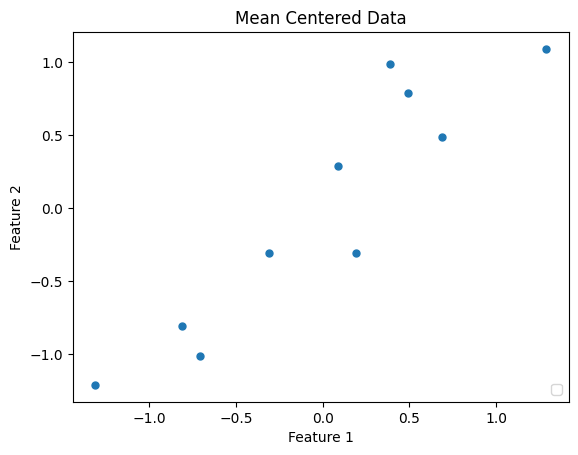

In [22]:
### center the data
x_mean = np.mean(x_np, axis=0)
x_centered = x_np - x_mean
print("Mean Centered Data",x_centered)
### plotting (asuuming 2d data for visulization)
plt.scatter(
    x_centered[:, 0],
    x_centered[:, 1],
    marker='o',
    s=25
)
plt.title("Mean Centered Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc='lower right')
plt.show()

In [23]:
## covariance matrix
cov_matrix = np.cov(x_centered.T)
print("Covariance Matrix",cov_matrix)

Covariance Matrix [[0.61655556 0.61544444]
 [0.61544444 0.71655556]]


In [24]:
### Eigen Decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvalues",eigenvalues)
print("Eigenvectors",eigenvectors)

Eigenvalues [0.0490834  1.28402771]
Eigenvectors [[-0.73517866 -0.6778734 ]
 [ 0.6778734  -0.73517866]]


In [25]:
## sorting the eigenvectors by eigenvalues desceding
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]
print("Sorted Eigenvalues",eigenvalues)
print("Sorted Eigenvectors",eigenvectors)

Sorted Eigenvalues [1.28402771 0.0490834 ]
Sorted Eigenvectors [[-0.6778734  -0.73517866]
 [-0.73517866  0.6778734 ]]


In [27]:
### Projecting the Data onto principal Componet
k = 1
principal_components = eigenvectors[:, :k]
projected_data = np.dot(x_centered, principal_components) ### like first
### w = eig_vec_sorted[:,1:k] then z = c_centered*w
print("Projected Data",projected_data)

Projected Data [[-0.82797019]
 [ 1.77758033]
 [-0.99219749]
 [-0.27421042]
 [-1.67580142]
 [-0.9129491 ]
 [ 0.09910944]
 [ 1.14457216]
 [ 0.43804614]
 [ 1.22382056]]


In [28]:
### Recontruction the approximation in original space
x_reconstructed = np.dot(projected_data, principal_components.T) + x_mean
print("Reconstructed Data",x_reconstructed)

Reconstructed Data [[2.37125896 2.51870601]
 [0.60502558 0.60316089]
 [2.48258429 2.63944242]
 [1.99587995 2.11159364]
 [2.9459812  3.14201343]
 [2.42886391 2.58118069]
 [1.74281635 1.83713686]
 [1.03412498 1.06853498]
 [1.51306018 1.58795783]
 [0.9804046  1.01027325]]


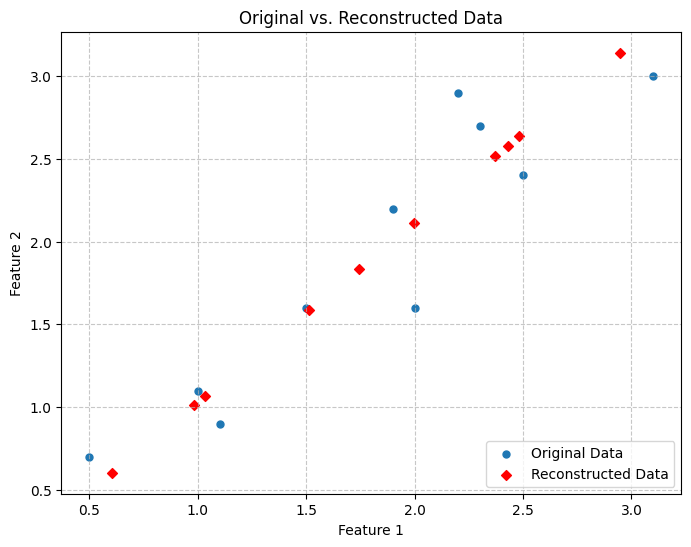

In [30]:
### Reconstructed Data in the Visual Form ::
plt.figure(figsize=(8, 6)) # Set a good figure size
plt.scatter(
    x_np[:, 0],
    x_np[:, 1],
    marker='o',
    s=25,
    label='Original Data'
)
plt.scatter(
    x_reconstructed[:, 0],
    x_reconstructed[:, 1],
    marker='D', # Diamond marker
    s=25,
    color='red', # Red color
    label='Reconstructed Data'
)
plt.title("Original vs. Reconstructed Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for readability
plt.show()

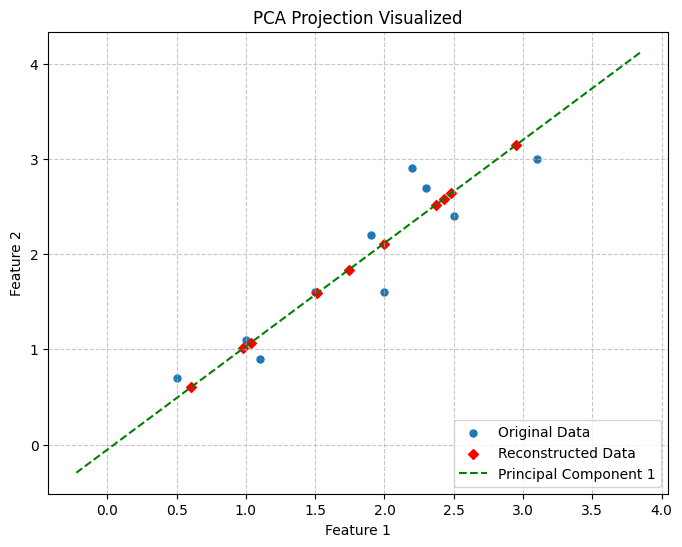

In [35]:
### ploting the Projection Visalized
plt.figure(figsize=(8, 6))
origin = np.mean(x_np, axis=0)
plt.scatter(
    x_np[:, 0],
    x_np[:, 1],
    marker='o',
    s=25,
    label='Original Data'
)
plt.scatter(
    x_reconstructed[:, 0],
    x_reconstructed[:, 1],
    marker='D', # Diamond marker
    s=25,
    color='red', # Red color
    label='Reconstructed Data'
)
direction = eigenvectors[:, 0]

# Create points along the principal component line
t = np.linspace(-3, 3, 100) # Adjust the range for 't' as needed
pc_line = origin + np.outer(t, direction)

plt.plot(pc_line[:, 0], pc_line[:, 1], color='green', linestyle='--', label='Principal Component 1')
plt.title("PCA Projection Visualized")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Conclusion ::
The data points lie close to a single direction, indicating strong correlation between features. The principal component captures most of the variance in the dataset. By projecting the data onto this direction, the dimensionality is reduced from 2D to 1D. The reconstructed points show that most information is preserved. Thus, PCA effectively removes redundancy and simplifies the dataset.